## Q1 — Model Year structure (Is the fleet concentrated in newer model years?)

This question examines how the registered EV vehicle population is distributed across Model Year. We want to understand whether the dataset is dominated by newer model years or spread across older years. The key output is the share of vehicles by model year, supported by simple visuals and summary statistics that highlight where most records are concentrated.

In [2]:
import pandas as pd
import numpy as np
from datetime import datetime

df = pd.read_csv("C:/Users/15386\OneDrive - UBC\Downloads\EV_analysis\data\wa_data_cleaned.csv")

MODEL_YEAR_COL = "Model Year"

print(df.shape)
print(df.columns)
print(df[MODEL_YEAR_COL].head())

(177477, 12)
Index(['County', 'City', 'State', 'Model Year', 'Make', 'Model',
       'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range',
       'Base MSRP', 'Vehicle Location', 'Electric Utility'],
      dtype='str')
0    2020
1    2023
2    2019
3    2016
4    2021
Name: Model Year, dtype: int64


In [3]:
# Group vehicles by model year, count how many vehicles fall in each year,
# then compute each year's share of the total vehicle population.
year_tbl = (
    df.groupby(MODEL_YEAR_COL)
    .size()
    .rename("count")
    .reset_index()
    .sort_values(MODEL_YEAR_COL)
)

year_tbl["share"] = year_tbl["count"] / year_tbl["count"].sum()

year_tbl.head(10), year_tbl.tail(10)

(   Model Year  count     share
 0        1997      1  0.000006
 1        1998      1  0.000006
 2        1999      5  0.000028
 3        2000      7  0.000039
 4        2002      2  0.000011
 5        2003      1  0.000006
 6        2008     19  0.000107
 7        2010     23  0.000130
 8        2011    775  0.004367
 9        2012   1614  0.009094,
     Model Year  count     share
 12        2015   4826  0.027192
 13        2016   5469  0.030815
 14        2017   8536  0.048096
 15        2018  14286  0.080495
 16        2019  10913  0.061490
 17        2020  11740  0.066149
 18        2021  19063  0.107411
 19        2022  27709  0.156127
 20        2023  57520  0.324098
 21        2024   7072  0.039847)

In [4]:
# Create a clean model year series, then calculate key summary statistics
# such as the earliest year, latest year, most common year, center, and spread.

y = df[MODEL_YEAR_COL].dropna().astype(int)

summary = {
    "min_year": int(y.min()),
    "max_year": int(y.max()),
    "mode_year": int(y.mode().iloc[0]) if not y.mode().empty else None,
    "median_year": float(y.median()),
    "mean_year": float(y.mean()),
    "p10_year": float(y.quantile(0.10)),
    "p90_year": float(y.quantile(0.90)),
}

summary

{'min_year': 1997,
 'max_year': 2024,
 'mode_year': 2023,
 'median_year': 2022.0,
 'mean_year': 2020.517097990162,
 'p10_year': 2016.0,
 'p90_year': 2023.0}

In [5]:
# Compute the share of vehicles that fall within the most recent N model years
max_year = int(y.max())

def recent_share(n_years: int) -> float:
    cutoff = max_year - (n_years - 1)
    return float((y >= cutoff).mean())

recent_3 = recent_share(3)
recent_5 = recent_share(5)
recent_7 = recent_share(7)

recent_3, recent_5, recent_7

(0.5200730235467131, 0.6936335412475982, 0.8356181364345803)

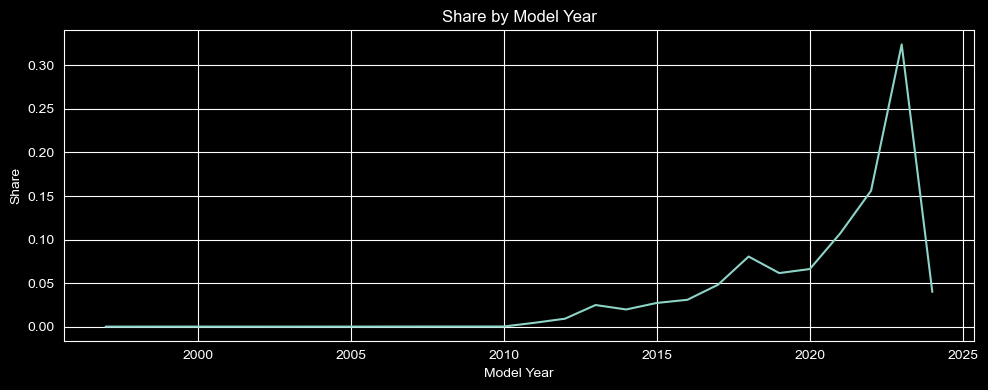

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.plot(year_tbl[MODEL_YEAR_COL].astype(int), year_tbl["share"])
plt.title("Share by Model Year")
plt.xlabel("Model Year")
plt.ylabel("Share")
plt.tight_layout()
plt.show()

This line chart shows the percentage of all registered EV records in each model year. The strong increase after ~2018 and peak around ~2023 indicate a new, recent-year–concentrated fleet, while the drop in the newest year is expected because the dataset only covers registrations up to March 2024, so the latest model-year data is incomplete.

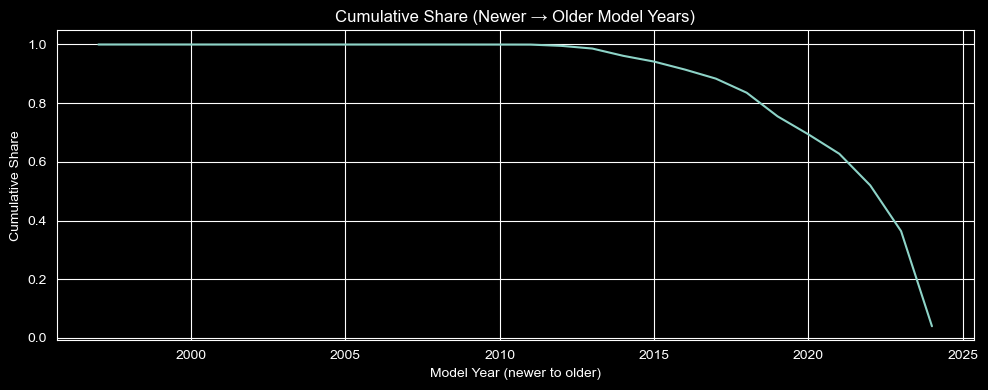

In [7]:
year_desc = year_tbl.sort_values(MODEL_YEAR_COL, ascending=False).copy()
year_desc["cum_share_new_to_old"] = year_desc["share"].cumsum()

plt.figure(figsize=(10,4))
plt.plot(year_desc[MODEL_YEAR_COL].astype(int), year_desc["cum_share_new_to_old"])
plt.title("Cumulative Share (Newer → Older Model Years)")
plt.xlabel("Model Year (newer to older)")
plt.ylabel("Cumulative Share")
plt.tight_layout()
plt.show()

This curve shows the cumulative percentage of vehicles captured as you include model years from newest to oldest. The steep rise in the newest years means a small number of recent model years already accounts for most registrations, and this pattern should be interpreted knowing the dataset is truncated at March 2024.

**Conclusion (Model Year structure)**\
The registered EV population in this dataset is strongly concentrated in newer model years, with most vehicles coming from the late 2010s onward and a clear peak around 2023, indicating a relatively new EV fleet in the region; the lower share for 2024 is expected because the data only covers registrations through March 2024.


In [8]:
# Simplify EV type labels and count each category.
EV_TYPE_COL    = "Electric Vehicle Type"

def map_ev_type(x):
    if pd.isna(x):
        return "Unknown"
    s = str(x).strip().upper()
    if "BATTERY" in s or s == "BEV":
        return "BEV"
    if "PLUGIN" in s or "PLUG-IN" in s or s == "PHEV":
        return "PHEV"
    return "Other"

df_q2 = df.copy()
df_q2["ev_type_simplified"] = df_q2[EV_TYPE_COL].apply(map_ev_type)

df_q2["ev_type_simplified"].value_counts(dropna=False)

ev_type_simplified
BEV     138948
PHEV     38529
Name: count, dtype: int64

In [9]:
# Count BEV and PHEV records overall and compute their market shares.
overall = (
    df_q2[df_q2["ev_type_simplified"].isin(["BEV", "PHEV"])]
    .groupby("ev_type_simplified")
    .size()
    .rename("count")
    .reset_index()
)

overall["share"] = overall["count"] / overall["count"].sum()
overall

,ev_type_simplified,count,share
0,BEV,138948,0.782907
1,PHEV,38529,0.217093


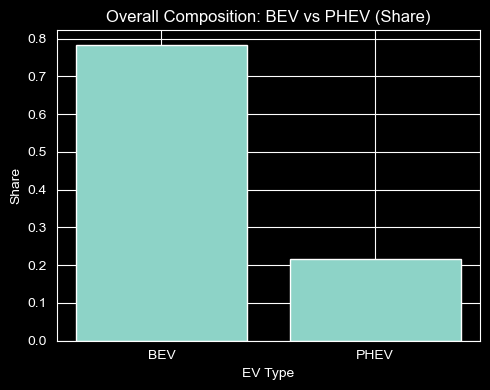

In [10]:
plt.figure(figsize=(5,4))
plt.bar(overall["ev_type_simplified"], overall["share"])
plt.title("Overall Composition: BEV vs PHEV (Share)")
plt.xlabel("EV Type")
plt.ylabel("Share")
plt.tight_layout()
plt.show()

This chart shows the overall market composition between BEVs and PHEVs in the dataset. BEVs account for a much larger share, at roughly two-thirds of the total, while PHEVs make up a much smaller portion. This suggests that the EV market in this dataset is clearly dominated by battery electric vehicles rather than plug-in hybrid electric vehicles.

In [11]:
# Count BEV and PHEV records by model year and reshape the result for comparison.
year_type = (
    df_q2[df_q2["ev_type_simplified"].isin(["BEV", "PHEV"])]
    .groupby([MODEL_YEAR_COL, "ev_type_simplified"])
    .size()
    .rename("count")
    .reset_index()
    .sort_values(MODEL_YEAR_COL)
)

pivot_counts = (
    year_type.pivot(index=MODEL_YEAR_COL, columns="ev_type_simplified", values="count")
    .fillna(0)
)

pivot_counts.head()

ev_type_simplified,BEV,PHEV
Model Year,,
1997,1.0,0.0
1998,1.0,0.0
1999,5.0,0.0
2000,7.0,0.0
2002,2.0,0.0


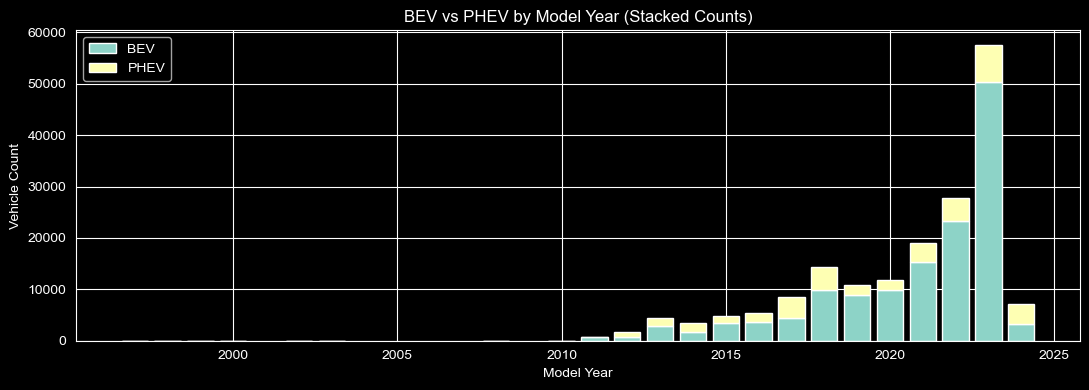

In [12]:
# Create a stacked bar chart showing BEV and PHEV counts for each model year.
plt.figure(figsize=(11,4))
plt.bar(pivot_counts.index.astype(int), pivot_counts.get("BEV", 0), label="BEV")
plt.bar(
    pivot_counts.index.astype(int),
    pivot_counts.get("PHEV", 0),
    bottom=pivot_counts.get("BEV", 0),
    label="PHEV"
)
plt.title("BEV vs PHEV by Model Year (Stacked Counts)")
plt.xlabel("Model Year")
plt.ylabel("Vehicle Count")
plt.legend()
plt.tight_layout()
plt.show()

This stacked bar chart shows that EV registrations are heavily concentrated in newer model years, with total vehicle counts rising sharply after about 2017 and peaking in 2023. Across almost every model year, BEVs make up the larger portion of the total, while PHEVs remain a smaller but still visible share. The especially large spike in 2023 suggests that the market is dominated by very recent vehicles, although the 2024 bar should be interpreted cautiously because the dataset only goes through March 2024 and therefore does not represent a full year. Overall, the graph suggests both a strong recent expansion in EV adoption and a consistent dominance of BEVs over PHEVs across model years.

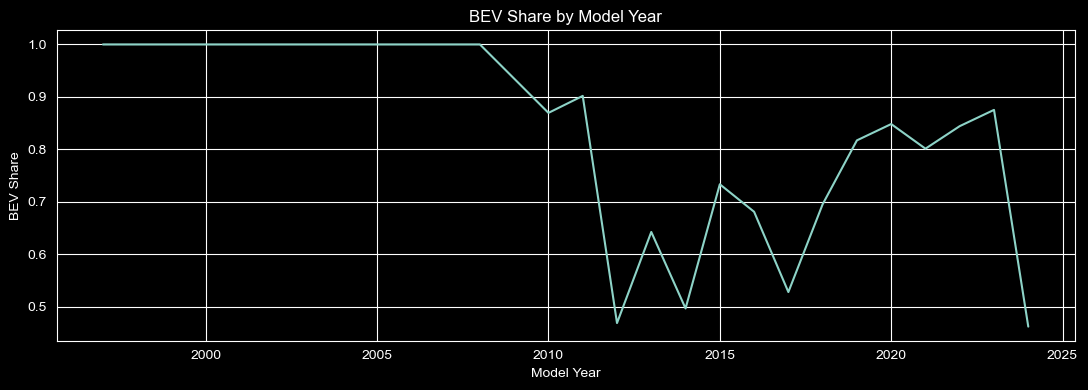

In [14]:
# Calculate the BEV share within each model year and plot how it changes over time.
year_total = pivot_counts.sum(axis=1)
bev_share = (pivot_counts.get("BEV", 0) / year_total).replace([np.inf, -np.inf], np.nan)

plt.figure(figsize=(11,4))
plt.plot(bev_share.index.astype(int), bev_share.values)
plt.title("BEV Share by Model Year")
plt.xlabel("Model Year")
plt.ylabel("BEV Share")
plt.tight_layout()
plt.show()

This plot shows how the share of BEVs (vs PHEVs) changes across model years. Overall, BEVs make up a large portion of the fleet in most years, especially in more recent model years where the BEV share is generally high (often around ~0.8–0.9), suggesting the market is increasingly oriented toward fully electric vehicles. The noticeable dips in some mid-2010s years likely reflect years where PHEVs had a stronger presence (and could also be affected by small sample sizes in those model years). The sharp drop at the newest model year is expected because your dataset only includes registrations up to March 2024, so the latest year is incomplete.
